# 01 — Mammography Preprocessing

Preprocessing pipeline for dual-view (CC + MLO) full-field digital mammograms.

**Pipeline:** artifact removal → breast-ROI crop → orientation normalization → pectoral-muscle removal (MLO only) → CLAHE → square resize-pad.

**Input:** `RAW_ROOT/{CC,MLO}/{Benign,Malign,Normal}/*.{png,jpg,...}`  
**Output:** `PROC_ROOT/{CC,MLO}/{Benign,Malign,Normal}/<name>_proc.png` (1024×1024, grayscale)

Deterministic and non-destructive: raw images are never modified.

In [2]:
# Configuration
!pip install -q opencv-python-headless tqdm

import os
import cv2
import warnings
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

matplotlib.rcParams.update({'figure.dpi': 150, 'font.size': 10})
warnings.filterwarnings('ignore')

# Auto-detect the raw data root (must contain CC/Benign and MLO/Benign).
RAW_CANDIDATES = [
    '/home/user/Projeler/Mamografi/raw',
    '/home/user/Projeler/Mamografi',
]
RAW_ROOT = next(
    (r for r in RAW_CANDIDATES
     if os.path.isdir(os.path.join(r, 'CC', 'Benign'))
     and os.path.isdir(os.path.join(r, 'MLO', 'Benign'))),
    None,
)
assert RAW_ROOT, f'No raw root with CC/Benign and MLO/Benign found in {RAW_CANDIDATES}. Set RAW_ROOT manually.'

PROC_ROOT   = '/home/user/Projeler/Mamografi/processed'
TARGET_SIZE = 1024
CLAHE_CLIP  = 2.0
CLAHE_TILE  = 8
VALID_EXTS  = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

# Raw subfolder -> processed relative path.
FOLDER_MAP = {
    'CC':  {'Benign': 'CC/Benign',  'Malign': 'CC/Malign',  'Normal': 'CC/Normal'},
    'MLO': {'Benign': 'MLO/Benign', 'Malign': 'MLO/Malign', 'Normal': 'MLO/Normal'},
}

print(f'RAW_ROOT   : {RAW_ROOT}')
print(f'PROC_ROOT  : {PROC_ROOT}')
print(f'TARGET_SIZE: {TARGET_SIZE}px | CLAHE clip={CLAHE_CLIP}, tile={CLAHE_TILE}x{CLAHE_TILE}')
for view in ('CC', 'MLO'):
    print(f'  RAW {view}: {sorted(os.listdir(os.path.join(RAW_ROOT, view)))}')
    for cls in ('Benign', 'Malign', 'Normal'):
        d = os.path.join(RAW_ROOT, view, cls)
        n = len([f for f in os.listdir(d) if f.lower().endswith(VALID_EXTS)]) if os.path.isdir(d) else 0
        print(f'    {view}/{cls}: {n} files')

RAW_ROOT   : /home/user/Projeler/Mamografi
PROC_ROOT  : /home/user/Projeler/Mamografi/processed
TARGET_SIZE: 1024px | CLAHE clip=2.0, tile=8x8
  RAW CC: ['.ipynb_checkpoints', 'Benign', 'Malign', 'Normal']
    CC/Benign: 300 files
    CC/Malign: 369 files
    CC/Normal: 300 files
  RAW MLO: ['.ipynb_checkpoints', 'Benign', 'Malign', 'Normal']
    MLO/Benign: 300 files
    MLO/Malign: 369 files
    MLO/Normal: 300 files


In [3]:
# Preprocessing functions

def remove_artifacts(gray, bgr=None):
    """Remove text annotations, scale bars and bright overlays.

    Strategies: (1) HSV color masking of yellow markers and white text;
    (2) morphological top-hat + connected-component analysis for small bright
    objects; (3) border-region bright suppression; (4) tissue-protection gate
    that excludes the two largest bright components (breast tissue);
    (5) adaptive inpainting (NS for sparse masks, TELEA otherwise).
    """
    H, W = gray.shape
    combined = np.zeros((H, W), dtype=np.uint8)

    # 1. HSV color masking
    if bgr is not None:
        hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
        yellow = cv2.inRange(hsv, np.array([15, 50, 80], np.uint8), np.array([45, 255, 255], np.uint8))
        white  = cv2.inRange(hsv, np.array([0, 0, 200], np.uint8), np.array([180, 35, 255], np.uint8))
        color_mask = cv2.dilate(cv2.bitwise_or(yellow, white), np.ones((5, 5), np.uint8), iterations=2)
        combined = cv2.bitwise_or(combined, color_mask)

    # 2. Morphological top-hat + connected-component analysis
    tophat = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, cv2.getStructuringElement(cv2.MORPH_RECT, (35, 35)))
    _, tophat_bin = cv2.threshold(tophat, 22, 255, cv2.THRESH_BINARY)
    n, labels, stats, _ = cv2.connectedComponentsWithStats(tophat_bin, connectivity=8)
    morph_mask = np.zeros_like(tophat_bin)
    for i in range(1, n):
        a = stats[i, cv2.CC_STAT_AREA]
        x0, y0 = stats[i, cv2.CC_STAT_LEFT], stats[i, cv2.CC_STAT_TOP]
        w0, h0 = stats[i, cv2.CC_STAT_WIDTH], stats[i, cv2.CC_STAT_HEIGHT]
        near_border = (x0 < W * 0.12 or x0 + w0 > W * 0.88 or y0 < H * 0.12 or y0 + h0 > H * 0.88)
        if (10 < a < 600) or (near_border and a < 5000):
            morph_mask[labels == i] = 255
    morph_mask = cv2.dilate(morph_mask, np.ones((5, 5), np.uint8), iterations=1)
    combined = cv2.bitwise_or(combined, morph_mask)

    # 3. Border-region bright suppression
    bh, bw = int(H * 0.12), int(W * 0.12)
    tissue_px = gray[gray > 10]
    t_mean = float(tissue_px.mean()) if len(tissue_px) > 100 else 50.0
    bright_thr = int(min(t_mean * 1.30, 230))
    border = np.zeros((H, W), dtype=np.uint8)
    border[:bh, :] = 255; border[H - bh:, :] = 255
    border[:, :bw] = 255; border[:, W - bw:] = 255
    bright_bdr = cv2.bitwise_and(border, (gray > bright_thr).astype(np.uint8) * 255)
    combined = cv2.bitwise_or(combined, bright_bdr)

    # 4. Tissue-protection gate
    _, otsu_bin = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    nb_t, lab_t, stats_t, _ = cv2.connectedComponentsWithStats(otsu_bin, connectivity=8)
    if nb_t >= 2:
        top2 = sorted(range(1, nb_t), key=lambda i: stats_t[i, cv2.CC_STAT_AREA], reverse=True)[:2]
        protect = np.zeros_like(gray, dtype=np.uint8)
        for idx in top2:
            protect[lab_t == idx] = 255
        protect_e = cv2.erode(protect, np.ones((17, 17), np.uint8), iterations=3)
        combined[protect_e > 0] = 0

    # 5. Adaptive inpainting
    mask_frac = float(combined.sum()) / (H * W * 255)
    method = cv2.INPAINT_NS if mask_frac < 0.04 else cv2.INPAINT_TELEA
    cleaned = cv2.inpaint(gray, combined, 7, method)
    return cleaned, combined


def crop_breast_roi(gray, pad_frac=0.02):
    """Crop to the largest Otsu connected component (breast) with relative padding."""
    blur = cv2.GaussianBlur(gray, (15, 15), 0)
    _, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    n, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    if n < 2:
        return gray
    largest = int(np.argmax(stats[1:, cv2.CC_STAT_AREA])) + 1
    x, y = stats[largest, cv2.CC_STAT_LEFT], stats[largest, cv2.CC_STAT_TOP]
    w, h = stats[largest, cv2.CC_STAT_WIDTH], stats[largest, cv2.CC_STAT_HEIGHT]
    H, W = gray.shape
    px, py = int(W * pad_frac), int(H * pad_frac)
    return gray[max(0, y - py):min(H, y + h + py), max(0, x - px):min(W, x + w + px)]


def normalize_orientation(gray):
    """Flip horizontally so breast tissue always faces right."""
    W = gray.shape[1]
    flip = bool(gray[:, :W // 2].mean() > gray[:, W // 2:].mean())
    return (cv2.flip(gray, 1) if flip else gray), flip


def remove_pectoral_mlo(gray, search_frac=0.45):
    """Conservative MLO pectoral-muscle removal.

    Searches the upper region for a bright triangular contour touching the top
    border near a lateral edge, fits a line to its inner boundary, and zeroes the
    pectoral side. Returns the image unchanged if no clear pectoral is found.
    """
    H, W = gray.shape
    sh = int(H * search_frac)
    upper = gray[:sh, :]
    blur = cv2.GaussianBlur(upper, (11, 11), 0)
    _, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    pect_cnt = None
    for cnt in sorted(contours, key=cv2.contourArea, reverse=True)[:5]:
        if cv2.contourArea(cnt) < 500:
            continue
        M = cv2.moments(cnt)
        if M['m00'] == 0:
            continue
        cx, cy = M['m10'] / M['m00'], M['m01'] / M['m00']
        if int(cnt[:, 0, 1].min()) < 5 and cy < sh * 0.4 and (cx < W * 0.3 or cx > W * 0.7):
            pect_cnt = cnt
            break
    if pect_cnt is None or len(pect_cnt) < 5:
        return gray
    vx, vy, x0, y0 = (float(v) for v in cv2.fitLine(pect_cnt, cv2.DIST_L2, 0, 0.01, 0.01))
    cx = cv2.moments(pect_cnt)['m10'] / cv2.moments(pect_cnt)['m00']
    result = gray.copy()
    for row in range(sh):
        col = int(x0 + (vx / vy) * (row - y0)) if abs(vy) > 1e-6 else int(x0)
        col = max(0, min(W - 1, col))
        if cx < W / 2:
            result[row, :col] = 0
        else:
            result[row, col:] = 0
    return result


def resize_pad(gray, size):
    """Aspect-ratio-preserving resize, zero-padded to a square canvas."""
    h, w = gray.shape
    scale = size / max(h, w)
    nh, nw = max(1, int(round(h * scale))), max(1, int(round(w * scale)))
    resized = cv2.resize(gray, (nw, nh), interpolation=cv2.INTER_AREA)
    canvas = np.zeros((size, size), dtype=np.uint8)
    canvas[(size - nh) // 2:(size - nh) // 2 + nh, (size - nw) // 2:(size - nw) // 2 + nw] = resized
    return canvas


def preprocess(img_path, target_size=1024, view='CC', clahe_clip=2.0, clahe_tile=8):
    """Run the full preprocessing pipeline on a single mammogram."""
    bgr = cv2.imread(img_path)
    if bgr is None:
        raise FileNotFoundError(f'Cannot load: {img_path}')
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    gray, art_mask = remove_artifacts(gray, bgr)
    gray = crop_breast_roi(gray)
    gray, flipped = normalize_orientation(gray)
    pectoral_removed = False
    if view.upper() == 'MLO':
        before = gray.copy()
        gray = remove_pectoral_mlo(gray)
        pectoral_removed = bool((before != gray).any())
    clahe = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=(clahe_tile, clahe_tile))
    gray = clahe.apply(gray)
    gray = resize_pad(gray, target_size)
    meta = {'view': view, 'artifact_px': int(art_mask.sum() // 255),
            'flipped': flipped, 'pectoral_removed': pectoral_removed}
    return gray, meta

print('Preprocessing functions loaded.')

Preprocessing functions loaded.


CC  sample : /home/user/Projeler/Mamografi/CC/Normal/10421168722.jpg
MLO sample : /home/user/Projeler/Mamografi/MLO/Normal/10421168722.jpg


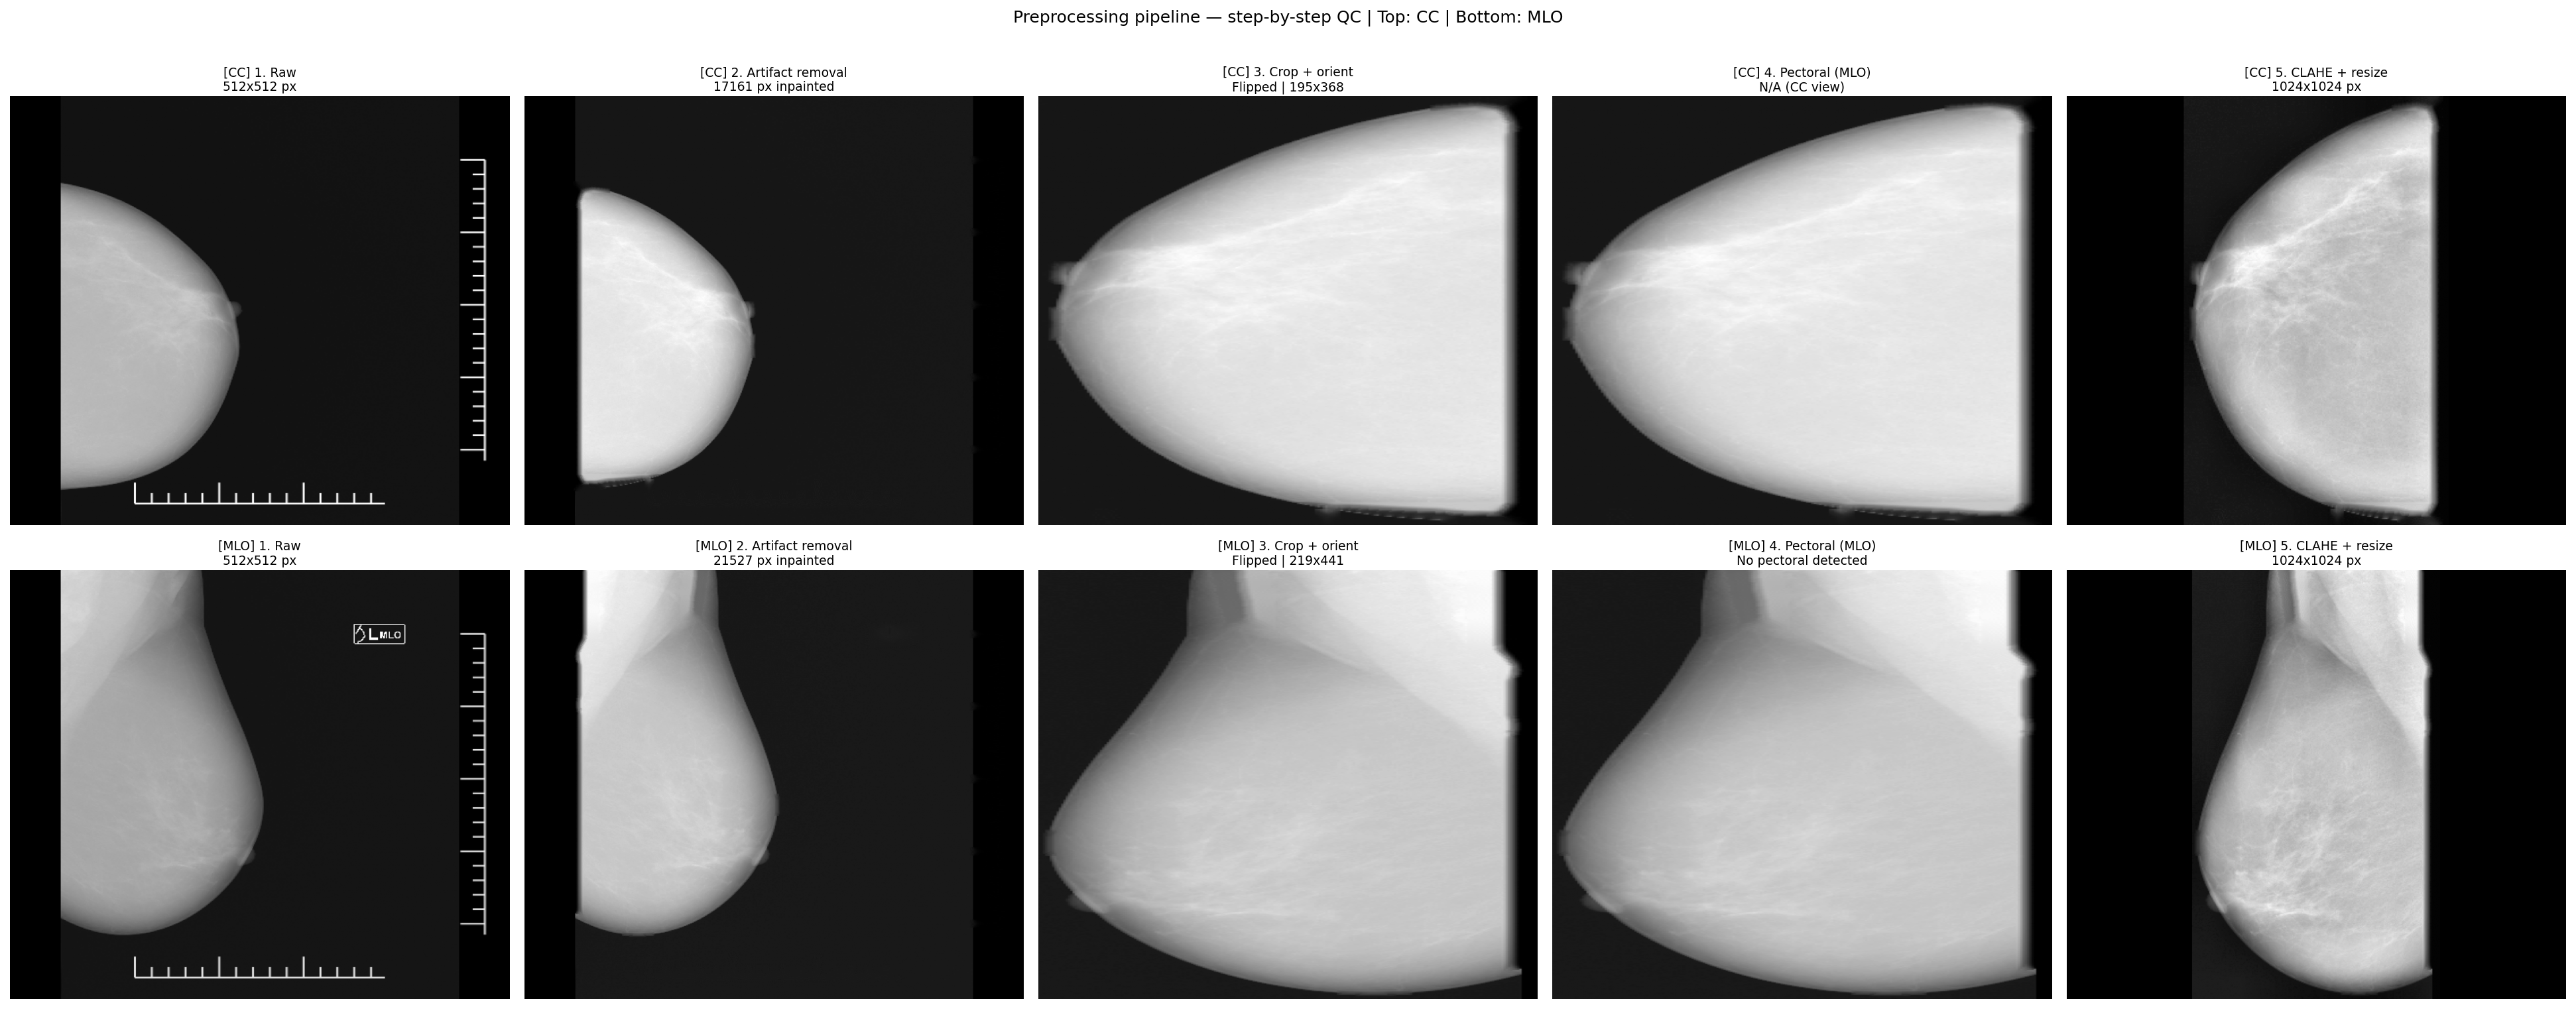

Saved: preprocessing_qc.png


In [4]:
# Quality-control visualization: CC and MLO, step by step

def find_first_image(folder):
    for dp, _, fs in os.walk(folder):
        for f in sorted(fs):
            if f.lower().endswith(VALID_EXTS):
                return os.path.join(dp, f)
    return None

test_cc  = find_first_image(os.path.join(RAW_ROOT, 'CC'))
test_mlo = find_first_image(os.path.join(RAW_ROOT, 'MLO'))
print(f'CC  sample : {test_cc}')
print(f'MLO sample : {test_mlo}')

STEP_LABELS = ['1. Raw', '2. Artifact removal', '3. Crop + orient', '4. Pectoral (MLO)', '5. CLAHE + resize']
fig, axes = plt.subplots(2, 5, figsize=(26, 10))

for ri, (path, view) in enumerate([(test_cc, 'CC'), (test_mlo, 'MLO')]):
    if path is None:
        for ax in axes[ri]:
            ax.axis('off')
        print(f'[WARN] No sample found for {view}')
        continue
    bgr = cv2.imread(path)
    gray0 = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    g1, art_mask = remove_artifacts(gray0.copy(), bgr)
    g2 = crop_breast_roi(g1)
    g3, flipped = normalize_orientation(g2)
    g4 = remove_pectoral_mlo(g3) if view == 'MLO' else g3.copy()
    clahe_op = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=(CLAHE_TILE, CLAHE_TILE))
    g5 = resize_pad(clahe_op.apply(g4), TARGET_SIZE)
    pect_note = ('Pectoral removed' if (g3 != g4).any()
                 else 'No pectoral detected' if view == 'MLO' else 'N/A (CC view)')
    details = [f'{gray0.shape[1]}x{gray0.shape[0]} px',
               f'{int(art_mask.sum() // 255)} px inpainted',
               f"{'Flipped' if flipped else 'No flip'} | {g3.shape[1]}x{g3.shape[0]}",
               pect_note,
               f'{TARGET_SIZE}x{TARGET_SIZE} px']
    for ci, (img, lbl, det) in enumerate(zip([gray0, g1, g3, g4, g5], STEP_LABELS, details)):
        ax = axes[ri, ci]
        ax.imshow(img, cmap='gray', aspect='auto')
        ax.set_title(f'[{view}] {lbl}\n{det}', fontsize=9, pad=4)
        ax.axis('off')

plt.suptitle('Preprocessing pipeline — step-by-step QC | Top: CC | Bottom: MLO', fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig('preprocessing_qc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: preprocessing_qc.png')

In [5]:
# Batch processing: all classes, both views

errors, summary = [], {}

for view, class_map in FOLDER_MAP.items():
    for raw_cls, proc_rel in class_map.items():
        raw_dir = os.path.join(RAW_ROOT, view, raw_cls)
        proc_dir = os.path.join(PROC_ROOT, proc_rel)
        if not os.path.isdir(raw_dir):
            print(f'[WARN] Not found: {raw_dir} — skipped')
            continue
        os.makedirs(proc_dir, exist_ok=True)
        files = sorted(f for f in os.listdir(raw_dir) if f.lower().endswith(VALID_EXTS))
        ok = 0
        for fname in tqdm(files, desc=f'{view}/{raw_cls}', leave=True):
            src = os.path.join(raw_dir, fname)
            dst = os.path.join(proc_dir, os.path.splitext(fname)[0] + '_proc.png')
            try:
                img, _ = preprocess(src, target_size=TARGET_SIZE, view=view,
                                    clahe_clip=CLAHE_CLIP, clahe_tile=CLAHE_TILE)
                cv2.imwrite(dst, img)
                ok += 1
            except Exception as exc:
                errors.append({'view': view, 'cls': raw_cls, 'file': fname, 'error': str(exc)})
        summary[f'{view}/{raw_cls}'] = {'ok': ok, 'total': len(files)}

print('\n' + '=' * 60)
print('  BATCH PROCESSING SUMMARY')
print('=' * 60)
tok = sum(v['ok'] for v in summary.values())
tall = sum(v['total'] for v in summary.values())
print(f'  Total: {tok}/{tall} processed')
for k, v in summary.items():
    print(f"  [{'OK' if v['ok'] == v['total'] else 'PARTIAL'}] {k}: {v['ok']}/{v['total']}")
if errors:
    print(f'\n  Errors ({len(errors)}):')
    for e in errors[:10]:
        print(f"    {e['view']}/{e['cls']}/{e['file']}: {e['error']}")
else:
    print('\n  No errors. All images processed cleanly.')
print(f'\n  Output: {PROC_ROOT}')
print('  Next: run 02_data_pipeline.ipynb')

CC/Benign:   0%|          | 0/300 [00:00<?, ?it/s]

CC/Malign:   0%|          | 0/369 [00:00<?, ?it/s]

CC/Normal:   0%|          | 0/300 [00:00<?, ?it/s]

MLO/Benign:   0%|          | 0/300 [00:00<?, ?it/s]

MLO/Malign:   0%|          | 0/369 [00:00<?, ?it/s]

MLO/Normal:   0%|          | 0/300 [00:00<?, ?it/s]


  BATCH PROCESSING SUMMARY
  Total: 1938/1938 processed
  [OK] CC/Benign: 300/300
  [OK] CC/Malign: 369/369
  [OK] CC/Normal: 300/300
  [OK] MLO/Benign: 300/300
  [OK] MLO/Malign: 369/369
  [OK] MLO/Normal: 300/300

  No errors. All images processed cleanly.

  Output: /home/user/Projeler/Mamografi/processed
  Next: run 02_data_pipeline.ipynb
